### Mind the Gap: Quantifying the Spatial and Economic Impact of Interagency Measurement Uncertainty in California Dairy Methane Inventories  
*Katharine Dickson, Ph.D.*

In early 2026, the [California Air Resources Board](https://ww2.arb.ca.gov) (CARB) sought feedback from the public on methane emissions regulation in the dairy and livestock sector in its [Information Solicitation to Inform Implementation of the Dairy and Livestock Provisions of Senate Bill 1383](https://ww2.arb.ca.gov/public-comments/information-solicitation-inform-dairy-and-livestock-sb1383). 

California [SB 1383 (Lara)](https://leginfo.legislature.ca.gov/faces/billNavClient.xhtml?bill_id=201520160SB1383) mandates that California achieve a reduction in its methane emissions by 40% below 2013 levels by the year 2030. Resolution 24-14 further directs CARB's Executive Officer (as of August 2026, Dr. Steven S. Cliff) to "prepare a plan for initiating, developing, proposing, and implementing a livestock methane regulation under Health and Safety Code 39730.7" including the following:
- The following timeline: rule development beginning in 2025, Board "consideration" by 2028, and "potential" regulatory implementation to commence by 2030.
- Evaluating data to better inform methane emission estimates and whether mandatory reporting and/or other requirements are appropriate, as called for by CARB and the [California Department of Food and Agriculture](https://www.cdfa.ca.gov)’s (CDFA) May 2024 response to a March 2024 [petition](https://ww2.arb.ca.gov/resources/documents/2024-livestock-methane-petition) by the state environmental nonprofit [Climate Action California](https://climateactionca.org).
- Incorporation of insights from current incentive structures, and an evaluation of their impact
- Determination of technological and economic feasibility
- Minimization of potential leakage
- Recognition that pre-2030 digester installations are not exempt from resulting regulations

Climate Action California submitted a [response](https://ww2.arb.ca.gov/form/public-comments/submissions/60256) to CARB's Information Solicitation. In its appendix, Dr. Daniel Chandler audited the concordance between California’s two primary dairy tracking datasets: the California Department of Food and Agriculture (CDFA) licensed dairy registry and the California Air Resources Board’s (CARB) CADD dataset. Tracking county-level facility counts from 2012 to 2022, the analysis revealed that while the datasets exhibit broad statistical correlation, they contain significant absolute discrepancies highly concentrated in the San Joaquin Valley, the state's primary agricultural hub (especially Merced and Tulare counties). By multiplying the divergent facility counts by county-level median herd sizes, Chandler demonstrated that this interagency data misalignment produces herd size discrepancies equivalent to 50,000 to 100,000 milking cows annually, with individual county-year differences running in both directions, indicating a measurement precision problem and not a systematic undercount. This notebook builds upon that baseline finding to quantify the geospatial, biogeochemical, and economic consequences of this uncertainty.

In this work, I build on Chandler's analysis by propagating this facility-level data discrepancy through state-level models for the period of 2012-2022. I first reproduce his concordance analysis, then isolate the uncertainty in the number of cattle by bootstrapping the interagency differences across county-years. I then apply published variance in dairy emissions factors to this distribution, utilizing Monte Carlo simulations to quantify the true magnitude of this regulatory uncertainty. Finally, I map these discrepancies geospatially across the San Joaquin Valley and translate the resulting methane variance into unpriced carbon liability under three economic scenarios.

First, some necessary housekeeping. The following datasets will be used in this work:  
- [CADD v2.0.0](https://ww2.arb.ca.gov/california-dairy-livestock-database-cadd), the California Dairy and Livestock Database, which contains facility-level cattle population and digester information for California dairies from 2012 to 2023. 
- CDFA Licensed Dairy Registry: County-level facility counts of licensed commercial dairies operating in California from 2012 to 2022 (obtained via Public Records Act request by Dr. Chandler, who provided them to me).

I am also importing [Geopandas 1.1.3](https://geopandas.org/en/stable/), a package specifically for working with geospatial data, to visualize the geographic concentration of these uncertainties.

The Python code below is designed to be run in order.

In [1]:
# Setup
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import scipy.stats as stats
from collections import defaultdict

BASE_PATH = "/Users/kd/Documents/Policy/MindTheGap/" # replace with the actual path to your project directory

# set constants that will be used in subsequent analyses
CONSTANTS = {
    "DATA_PATH": "data/raw/",
    "CARB_MAY26_PRICE": 28.81, # CARB Cap-and-Invest May 2026 Joint Auction 47 Current Auction Settlement Price (USD/MTCO2e)
    "SOC_COST_CARBON": 185, # Social Cost of Carbon (SCC): $185/ton CO2e, estimated by Resources for the Future (RFF) in 2022 - see "The Social Cost of Carbon: Reaching a New Estimate" by Prest, Wingenroth, and Rennert
    "EQUITY_SCC": 265, # Equity-Weighted Social Cost of Carbon: $265/ton CO2e, calculated for 2025 by the UC Santa Cruz Office of Sustainability (https://sustainability.ucsc.edu/initiatives/climate-energy-and-decarbonization/social-cost-of-carbon/)
    "CARB_EF_MILKCOW": 144.61, # enteric fermentation emission factor from CARB (2014) for lactating dairy cows (kg CH4/cow/year)
    "CARB_EF_MILKCOW_SD": 144.61 * 0.074, # standard deviation of enteric fermentation emission factor from CARB (2014) for lactating dairy cows (kg CH4/cow/year) multiplied by 365 days to convert to kg CH4/cow/year: CARB_EF_MILKCOW multiplied by 0.074 to get standard deviation (kg CH4/cow/year)
    }

# import data
ca_counties = gpd.read_file(BASE_PATH + CONSTANTS["DATA_PATH"] + "California_County_Boundary_view_layer_for_public_use_8037095093810267993.zip") # California county boundary shapefile, from the California State Geoportal (https://gis.data.ca.gov/datasets/894e9cda46bb45c2a0c7b5534b9a6b4a_3/explore)
cadd_facility_df = pd.read_csv(BASE_PATH + CONSTANTS["DATA_PATH"] + "cadd_facility_data.csv") # CADD v2.0.0 Excel spreadsheet - Facility General Information tab
cadd_herdsize_df = pd.read_csv(BASE_PATH + CONSTANTS["DATA_PATH"] + "cadd_herdsize_data.csv") # CADD v2.0.0 Excel spreadsheet - Facility Herd Size tab
cdfa_df = pd.read_csv(BASE_PATH + CONSTANTS["DATA_PATH"] + "cdfa_data_portfolioready.csv") # CDFA data provided by Dr. Dan Chandler. Cleaned and formatted for analysis and clean merging with CADD dataframes - see README.md in GitHub repository for details on how this data was cleaned and formatted.

# merge CADD dataframes into a single consolidated CADD dataframe
cadd_merged_df = pd.merge(cadd_facility_df, cadd_herdsize_df, on="CADDID", how="left") # straightforward merge of facility and herd size data.


### Step 1: Concordance Analysis Replication
I first carry out a concordance analysis ([Lin's Concordance Correlation Coefficient](https://nirpyresearch.com/concordance-correlation-coefficient/)) to verify Chandler's calculated $\rho_c$ of 0.996.

In [2]:
# define a function to calculate Lin's Concordance Correlation Coefficient
def lins_ccc(x, y):
    """
    Calculate Lin's Concordance Correlation Coefficient (CCC, rho_c or rhoC) between two arrays.

    rho_c = 2(cov(x, y)) / (var(x) + var(y) + (mean(x) - mean(y))^2)
    
    Parameters:
    x (array-like): First array of data.
    y (array-like): Second array of data.
    
    Returns:
    float: Lin's CCC value.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    
    cov_xy = np.cov(x, y, ddof=1)[0][1]
    
    ccc = (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)
    
    return ccc 

# CADD Data Filtration
cadd_merged_dairies = cadd_merged_df[cadd_merged_df['LabeledAsDairy'] == 1].copy() # filter for only dairy facilities in the CADD dataset
cols_to_sum = ['MilkCows', 'DryCows', 'OldHeifers', 'YoungHeifers', 'OldCalves', 'BeefCattle'] # create a variable for the columns to sum
cadd_merged_dairies[cols_to_sum] = cadd_merged_dairies[cols_to_sum].replace({',': ''}, regex=True).apply(pd.to_numeric, errors='coerce').fillna(0) # clean dirty string data by removing commas and forcing data to int
cadd_merged_dairies['Total_Herd_Size'] = cadd_merged_dairies[cols_to_sum].sum(axis=1) # obtain sum of all cattle for each dairy facility in the CADD dataset. We expect 'BeefCattle' to be 0 in all instances but add it for completeness.
cadd_merged_dairies_county_year = cadd_merged_dairies.groupby(['County', 'Year']).agg(cadd_dairy_count=('CADDID', 'nunique')).reset_index() # aggregate dairy CADD data to get facility counts per county per year

# CDFA Data Filtration
cdfa_df['cdfa_cowdairy_count'] = cdfa_df[['MktMilkDairiesCow', 'MfgMilkDairiesCow']].sum(axis=1) # obtain sum of cattle dairies for each county in the CDFA dataset. Mkt = market milk dairies, Mfg = manufacturing milk dairies.


# merge CADD and CDFA dataframes for Lin's Concordance Correlation Coefficient calculation
cadd_merged_dairies_county_year['Year'] = cadd_merged_dairies_county_year['Year'].astype(int) # force Year to int in CADD to ensure a clean merge
cdfa_df['Year'] = cdfa_df['Year'].astype(int) # force Year to int in CDFA for the same reason
compare_df = pd.merge(cadd_merged_dairies_county_year, cdfa_df, on=['County', 'Year'], how='inner', validate='one_to_one') # merge CADD and CDFA dataframes on County and Year for comparison
print(f"Total rows in compare_df: {len(compare_df)}")

# Lin's Concordance Correlation Coefficient between CADD and CDFA herd sizes for dairy facilities
lins_CDFA_CADD = lins_ccc(compare_df['cadd_dairy_count'], compare_df['cdfa_cowdairy_count']) # compute concordance between CADD and CDFA cattle dairy counts; CADD only reports cattle dairies, whereas CDFA reports both cattle and non-cattle dairies. The concordance should be high but not 100%.
print(f"Lin's Concordance Correlation Coefficient between CADD and CDFA for dairy facility numbers: {lins_CDFA_CADD:.4f}") # print the result with 4 decimal places

Total rows in compare_df: 332
Lin's Concordance Correlation Coefficient between CADD and CDFA for dairy facility numbers: 0.9982


### Step 2: Bootstrapping

Chandler approximated the size of the interagency data gap by multiplying the absolute difference in facility counts by county-level median herd sizes; while this is useful as a preliminary figure, it introduces false precision and obscures directionality. 

Where CADD reports more facilities than CDFA, herd sizes for those facilities are known, which more likely reflects licensing or timing discrepancies over emissions data gaps. Real estimation uncertainty exists only where CDFA's licensed-dairy count exceeds CADD's facility count, since those are dairies with legally documented existence but no corresponding emissions characterization.

To rigorously quantify this uncertainty, I replace the arithmetic point estimate with a probabilistic model. For every county-year combination where CDFA facility counts exceed CADD counts, I employ a Monte Carlo bootstrapping approach: I randomly sample $n$ herd sizes (where $n$ is the positive difference in facilities) directly from the known CADD herd size distribution for that county-year combination.

Iterating this sampling process 10,000 times with replacement yields a robust probability distribution of the unaccounted cattle population per county-year. These independent arrays are then summed element-wise to generate statewide uncertainty bands, allowing us to define the uncertainty in the state's herd count using 95% confidence intervals.

(The default RNG seed has been set to 1383 as a nod to SB 1383.)

In [3]:
def bootstrap_discrepant_cattle(herd_sizes, num_discrepant_dairies, n_iterations=10000, rng=1383):
    """
    Bootstrap total cattle counts for dairies counted by CDFA but not by CADD, per county-year.
    Only applicable when CDFA's dairy count is larger than CADD's (i.e. num_discrepant_dairies > 0). If num_discrepant_dairies is 0, the function returns an array of zeros.
    
    MODEL LIMITATION NOTE: Assumes other dairies' herd sizes come from the same distribution as the herd sizes in the CADD dataset.
    
    Parameters:
    herd_sizes (array-like): Array of herd sizes for dairy facilities.
    num_discrepant_dairies (int): Number of discrepant dairies to sample in each iteration (CDFA - CADD).
    n_iterations (int): Number of bootstrap iterations.

    Returns:
    np.ndarray: Array of total discrepant cattle for each iteration.
    """
    # if no discrepancy, return an array of zeros
    if num_discrepant_dairies == 0:
        return np.zeros(n_iterations)

    valid_herds = np.asarray(herd_sizes, dtype=float) # ensure herd_sizes is a numpy array
    valid_herds = valid_herds[~np.isnan(valid_herds)] # drop NaNs

    if len(valid_herds) == 0:
        raise ValueError("No valid herd sizes available for sampling.")

    # randomly sample 'num_discrepant_dairies' with replacement for each iteration, generate matrix of shape (n_iterations, num_discrepant_dairies)
    generator = np.random.default_rng(rng) # set random number generator with specified seed, or 1383 if not otherwise specified
    sampled_herd_sizes = generator.choice(valid_herds, size=(n_iterations, num_discrepant_dairies), replace=True)

    # sum across rows for each iteration to obtain the total discrepant cattle
    total_discrepant_cattle = sampled_herd_sizes.sum(axis=1)

    return total_discrepant_cattle

compare_df['dairy_count_discrepancy'] = compare_df['cdfa_cowdairy_count'] - compare_df['cadd_dairy_count'] # calculate discrepancy in dairy counts between CDFA and CADD
discrepant_county_years = compare_df[compare_df['dairy_count_discrepancy'] > 0][['County', 'Year', 'dairy_count_discrepancy']] # filter for county-years where CDFA > CADD
bootstrap_samples = {} # (County, Year): array containing total discrepant cattle per bootstrap iteration
skipped_county_years = [] # for tracking county-years with no valid herd sizes for bootstrapping
summary_stats = [] # store summary statistics for each county-year

print(f"Rows where CDFA > CADD: {len(discrepant_county_years)}")

cadd_merged_dairies['Year'] = cadd_merged_dairies['Year'].astype(int) # force Year to int


# Bootstrapping for each county-year with a discrepancy in dairy counts
for county, year, gap in discrepant_county_years.itertuples(index=False):
    herd_sizes = cadd_merged_dairies[(cadd_merged_dairies['County'] == county) & (cadd_merged_dairies['Year'] == year)]['Total_Herd_Size'] # get herd sizes for the specific county-year from CADD data

    # if there are no valid herd sizes for this county-year, skip to the next iteration
    if len(herd_sizes) == 0:
        skipped_county_years.append((county, year))
        continue

    # perform bootstrapping to estimate total discrepant cattle for this county-year
    total_discrepant_cattle = bootstrap_discrepant_cattle(herd_sizes, gap)
    bootstrap_samples[(county, year)] = total_discrepant_cattle

    # calculate summary statistics
    mean_discrepant = np.mean(total_discrepant_cattle)
    median_discrepant = np.median(total_discrepant_cattle)
    lower_ci = np.percentile(total_discrepant_cattle, 2.5)
    upper_ci = np.percentile(total_discrepant_cattle, 97.5)

    # append summary statistics to the list
    summary_stats.append({
        'County': county,
        'Year': year,
        'Mean_Discrepant_Cattle': mean_discrepant,
        'Median_Discrepant_Cattle': median_discrepant,
        'Lower_CI_2.5%': lower_ci,
        'Upper_CI_97.5%': upper_ci
    })

# convert summary statistics list to a DataFrame for easier analysis and visualization
discrepant_summary_df = pd.DataFrame(summary_stats) # convert summary statistics list to dataframe
discrepant_summary_df.sort_values(by=['County', 'Year'], inplace=True) # sort summary dataframe by county and year

if skipped_county_years:
    print(f"Skipped the following county-years due to no valid herd sizes for bootstrapping: {skipped_county_years}")
    for county, year in skipped_county_years:
        print(f" - {county}, {year}")

samples_by_county_year = defaultdict(list) # dictionary to hold bootstrap samples by county-year
for (county, year), samples in bootstrap_samples.items():
    samples_by_county_year[(county, year)] = samples

known_cattle_by_year = cadd_merged_dairies.groupby('Year')['Total_Herd_Size'].sum() # known cattle counts from CADD data, aggregated by year

year_summary_stats = [] # store summary statistics for each year
for year in sorted(compare_df['Year'].unique()):
    # get known cattle count for the year
    known_cattle = known_cattle_by_year.get(year, 0)
    arrs = [samples for (county, y), samples in bootstrap_samples.items() if y == year]

    # if there are no bootstrap samples for the year, create an array of zeros to maintain consistency in summary statistics calculation
    if len(arrs) == 0:
        print(f"No bootstrap samples available for year {year}. Skipping summary statistics calculation.")
        discrepant = np.zeros(10000)  # Assuming 10,000 iterations for consistency)
    else:
        discrepant = np.sum(arrs, axis=0)

    # calculate summary statistics for the year
    mean_discrepant = np.mean(discrepant)
    median_discrepant = np.median(discrepant)
    lower_ci = np.percentile(discrepant, 2.5)
    upper_ci = np.percentile(discrepant, 97.5)

    # append summary statistics to the list
    year_summary_stats.append({
        'Year': year,
        'Known_Cattle': known_cattle,
        'Mean_Discrepant_Cattle': mean_discrepant,
        'Median_Discrepant_Cattle': median_discrepant,
        'Lower_CI_2.5%': lower_ci,
        'Upper_CI_97.5%': upper_ci
    })

yearly_discrepant_summary_df = pd.DataFrame(year_summary_stats) # convert yearly summary statistics list to dataframe
print(yearly_discrepant_summary_df.to_string(index=False)) # print the yearly summary statistics dataframe

Rows where CDFA > CADD: 141
 Year  Known_Cattle  Mean_Discrepant_Cattle  Median_Discrepant_Cattle  Lower_CI_2.5%  Upper_CI_97.5%
 2012     2895418.0              98347.6750                   97237.5      70187.625      133588.500
 2013     2804679.0             110770.9905                  109932.5      83470.600      142576.025
 2014     2759891.0             261377.0712                  260542.5     217532.500      309486.475
 2015     2740349.0             128700.9704                  127820.5      99082.775      163208.425
 2016     2732772.0             138315.2775                  137271.0     106412.000      174856.425
 2017     2708478.0             108721.5103                  108004.5      80833.875      141221.350
 2018     2657283.0             107376.0283                  106531.0      81566.500      137890.075
 2019     2619126.0              89070.9523                   88266.5      65101.450      117341.775
 2020     2598592.0             101066.8571                  10

### Step 3: Error Propagation and Monte Carlo Combination with Step 2

Measurement, reporting, and verification (MRV) of dairy methane emissions is difficult due to the impracticality of facility-level direct measurements at scale. Consequently, researchers frequently rely on proxy data, such as herd counts, combined with modeled emissions factors that vary depending on methodology. Translating structural uncertainty in herd counts into atmospheric impact in the absence of external measurements, therefore, requires applying an emissions factor to bridge count-level and emissions-level uncertainty. At the same time, utilizing a factor treated as a fixed, static multiplier ignores the inherent biological variance of enteric and manure emissions.

I draw on emissions factors from the literature to calculate the variance in California dairy cattle methane emissions. This step distinguishes between animal-to-animal variance and uncertainty in the mean to ensure the correct probabilistic distribution is applied to an aggregated county-level estimate. By defining the emissions factor as a probability distribution instead of a static constant, we can accurately propagate the biological uncertainty into the final model.

This analysis covers only methane from enteric fermentation by lactating cows; manure emissions require facility-level storage system data not available in the current dataset and are therefore excluded.

The emissions factor used is from E1 in Table 3 in Marklein *et al*. (2021): 144.61 kg $\text{CH}_4$/cow/year (SE 7.4%, sensitivity 12.0%) for enteric methane from lactating cows.

We use CARB's own enteric fermentation methodology as the emissions factor for two reasons. This method underpins California's official GHG inventory, and the regulatory accounting I audit here. Using either E2 or E3 in this paper would create an internal inconsistency between the system being examined and the method used in its examination. E1 also carries the lowest reported uncertainty, making it the most conservative choice. The analysis is for lactating cows only because E1 only provides an emissions factor for this class of cattle and does not publish corresponding factors for others. I exclude emissions factors derived from other methods to maintain methodological consistency, though this understates total enteric methane.

Finally, to calculate the total unaccounted methane ($\text{MTCO}_2\text{e}$), I combine the bootstrapped herd-discrepancy distribution (Step 2) with the lactating cow enteric emissions distribution. I employ a Monte Carlo simulation instead of relying on analytical error propagation. For each of the 10,000 iterations, the model simultaneously draws from the herd-difference distribution and the emissions-factor distribution, multiplying them to collect a full spectrum of possible outcomes. The resulting output is a complete probability distribution of uncertain $\text{MTCO}_2\text{e}$, allowing us to report the 5th, 50th (median), and 95th percentiles of regulatory uncertainty, thereby avoiding the false precision of a single point estimate.

NOTE: Table 3 of Marklein *et al*. (2021) contains a unit-notation error, listing the E1 emissions factor as 144.61 kg methane per head "per day." Because a cow consuming ~25 kg of dry matter daily cannot physically emit 144 kg of methane, I have correctly applied 144.61 as the annual per-head emissions factor (kg $\text{CH}_4$/head/year), aligning with established biological constraints.

Marklein *et al*. (2021). "[Facility-scale inventory of dairy methane emissions in California: implications for mitigation.](https://doi.org/10.5194/essd-13-1151-2021)" *Earth Syst. Sci. Data* 13: 1151-1166.


In [4]:
# NOTE: this step should take approximately 1 minute and 30 seconds to run
# function 1: derive facility-level total lactating cow enteric emissions
def facility_emissions(milkcows, ef_milkcow=CONSTANTS["CARB_EF_MILKCOW"]):
    """
    Calculate total emissions for a dairy facility based on the number of lactating cows and the emission factor.
    
    Parameters:
    milkcows (int): Number of lactating cows at the facility.
    ef_milkcow (float): Emission factor for lactating cows (kg CH4/cow/year). Default is CARB_EF_MILKCOW.

    Returns:
    float: Total emissions for the facility (kg CH4/year).
    """
    return milkcows * ef_milkcow

# test function 1; expected answer should be 500 * 144.61 = 72,305 kg CH4/year
testemissions = facility_emissions(milkcows=500)
print(f"\nTest: 500 lactating cows produce {testemissions:,.2f} kg CH4/year")

# function 2: pull one county-year's CADD records
def get_herd_records(cadd_merged_dairies, county, year):
    """
    Retrieve herd records for a specific county and year from the CADD merged dairies dataframe.
    
    Parameters:
    cadd_merged_dairies (dataframe): Merged CADD dairies dataframe.
    county (str): County name to filter by.
    year (int): Year to filter by.

    Returns:
    dataframe: Filtered herd records for the specified county and year.
    """
    return cadd_merged_dairies[(cadd_merged_dairies['County'] == county) & (cadd_merged_dairies['Year'] == year)]

# function 3: one bootstrap draw - herd resampling and EF uncertainty combined
def single_bootstrap_instance(herd_pool, n_missing, rng):
    """
    Perform a single bootstrap instance to estimate total emissions for missing dairies.
    
    Parameters:
    herd_pool (dataframe): dataframe containing herd records to sample from.
    n_missing (int): number of missing dairies to sample.
    rng (int): random seed for reproducibility.

    Returns:
    float: total emissions for the sampled missing dairies.
    """
    if len(herd_pool) == 0:
        return np.nan
 
    sampled_indices = rng.choice(len(herd_pool), size=n_missing, replace=True)
    sampled = herd_pool.iloc[sampled_indices]
 
    ef_milk_cow_draw = rng.normal(CONSTANTS["CARB_EF_MILKCOW"], CONSTANTS["CARB_EF_MILKCOW_SD"])
 
    total_emissions = facility_emissions(
        sampled['MilkCows'].values,
        ef_milkcow=ef_milk_cow_draw
    ).sum()
 
    return total_emissions

# function 4: many bootstrap draws for one county-year
def bootstrap_county_year(herd_pool, n_missing, n_iterations=10000, seed=None):
    rng = np.random.default_rng(seed)
    if len(herd_pool) == 0 or n_missing <= 0:
        return np.full(n_iterations, np.nan)
 
    draws = np.array([
        single_bootstrap_instance(herd_pool, n_missing, rng)
        for _ in range(n_iterations)
    ])
    return draws

# function 5: combine all discrepant county-years into a single statewide distribution
def run_full_bootstrap(discrepancy_df, cadd_merged_df, n_iterations=10000, seed=1383):
    """
    Parameters:
    discrepancy_df: filtered (CDFA > CADD) county-year table with columns County, Year, dairy_count_discrepancy (the signed difference).
    cadd_merged_df:
    n_iterations (default 10000): number of bootstrap iterations.
    seed (default 1383): RNG seed for reproducibility.

    Returns:
    statewide_total: array of length n_iterations containing the statewide emissions distribution (kg CH4/year).
    """
    statewide_total = np.zeros(n_iterations)
 
    for _, row in discrepancy_df.iterrows():
        pool = get_herd_records(cadd_merged_df, row['County'], row['Year'])
        draws = bootstrap_county_year(
            pool, row['dairy_count_discrepancy'], n_iterations=n_iterations, seed=seed
        )
        statewide_total += np.nan_to_num(draws, nan=0.0)
 
    return statewide_total

# run the full pipeline
statewide_distribution_kg = run_full_bootstrap(discrepant_county_years, cadd_merged_dairies)
statewide_distribution_mtco2e = (statewide_distribution_kg / 1000) * 28  # GWP-100 = 28 for CH4
print(np.percentile(statewide_distribution_mtco2e, [5, 50, 95]))


Test: 500 lactating cows produce 72,305.00 kg CH4/year
[2690062.54154595 2911101.47922292 3145468.97155182]


### Step 4: Chloropleth Map of Uncertainty Magnitudes in California Counties

Climate risk and regulatory uncertainty are inherently spatial. To understand where the state's data infrastructure is most fragile, I merge the median absolute discrepancy (from the Monte Carlo $\text{MTCO}_2\text{e}$ distribution) for each county with California county shapefiles.

The resulting choropleth map of California counties visualizes the geographic concentration of measurement uncertainty. This spatial analysis does not indicate definitively "hidden" emissions, but instead highlights regions where interagency data misalignment severely degrades regulatory confidence—which notably overlap with some of the state's most heavily burdened environmental justice (EJ) communities.

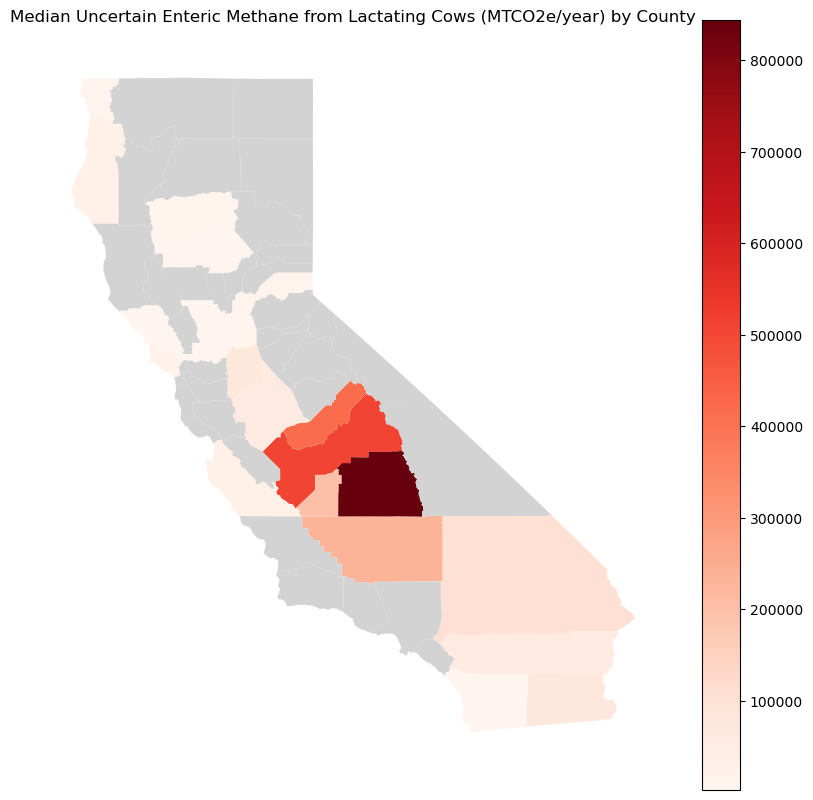

In [5]:
def run_geo_bootstrap(discrepancy_df, cadd_merged_df, n_iterations=10000, seed=1383): # similar procedure to run_full_bootstrap from previous step
    statewide_total = np.zeros(n_iterations)
    county_results = []

    for _, row in discrepancy_df.iterrows():
        pool = get_herd_records(cadd_merged_df, row['County'], row['Year'])
        draws = bootstrap_county_year(
            pool, row['dairy_count_discrepancy'], n_iterations=n_iterations, seed=seed
        )
        draws_clean = np.nan_to_num(draws, nan=0.0)
        statewide_total += draws_clean

        county_mtco2e_median = np.median((draws_clean / 1000) * 28)
        county_results.append({'County': row['County'], 'Year': row['Year'], 'Median_MTCO2e': county_mtco2e_median})

    county_results_df = pd.DataFrame(county_results)
    return statewide_total, county_results_df

_, county_results_df = run_geo_bootstrap(discrepant_county_years, cadd_merged_dairies)
county_totals = county_results_df.groupby('County')['Median_MTCO2e'].sum().reset_index()

merged = ca_counties.merge(county_totals, left_on='COUNTY_NAM', right_on='County', how='left') # merge county shapefile data

fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(column='Median_MTCO2e', cmap='Reds', legend=True, ax=ax,
            missing_kwds={'color': 'lightgrey'})
ax.set_title('Median Uncertain Enteric Methane from Lactating Cows (MTCO2e/year) by County')
ax.axis('off')
plt.show()

### Step 5: Three Carbon Price Scenarios

Finally, to quantify the financial exposure created by this regulatory uncertainty, I apply three distinct carbon pricing scenarios to the Monte Carlo $\text{MTCO}_2\text{e}$ distribution:
- Most Recent California Cap-and-Trade Price: 28.81 USD per $\text{MTCO}_2\text{e}$, representing the immediate compliance market exposure (May 2026 Joint Auction, Current Auction Settlement Price in USD).
- Social Cost of Carbon (SCC): 185 USD/$\text{MTCO}_2\text{e}$), estimated by Resources for the Future (RFF) in 2022 - see "The Social Cost of Carbon: Reaching a New Estimate" by Prest, Wingenroth, and Rennert.
- Equity-Weighted SCC: 265 USD/$\text{MTCO}_2\text{e}$, calculated for 2025 by the [UC Santa Cruz Office of Sustainability](https://sustainability.ucsc.edu/initiatives/climate-energy-and-decarbonization/social-cost-of-carbon/).

This yields a probabilistic range of dollar exposure under each scenario.

In [6]:
# scenario 1: California Cap-and-Invest
cap_invest_exposure = statewide_distribution_mtco2e * CONSTANTS["CARB_MAY26_PRICE"]

# scenario 2: baseline Social Cost of Carbon
scc_exposure = statewide_distribution_mtco2e * CONSTANTS["SOC_COST_CARBON"]

# scenario 3. Equity-Weighted SCC
equity_scc_exposure = statewide_distribution_mtco2e * CONSTANTS["EQUITY_SCC"]

def print_financial_uncertainty(name, distribution):
    median_val = np.median(distribution)
    lower_ci = np.percentile(distribution, 2.5)
    upper_ci = np.percentile(distribution, 97.5)
    print(f"{name}:")
    print(f"  Median Liability: ${median_val:,.2f}")
    print(f"  95% CI: [${lower_ci:,.2f} - ${upper_ci:,.2f}]\n")

print("--- UNPRICED FINANCIAL LIABILITY OF REGULATORY UNCERTAINTY ---\n")
print_financial_uncertainty("1. Cap-and-Invest Exposure", cap_invest_exposure)
print_financial_uncertainty("2. Federal Social Cost of Carbon", scc_exposure)
print_financial_uncertainty("3. Equity-Weighted SCC", equity_scc_exposure)


--- UNPRICED FINANCIAL LIABILITY OF REGULATORY UNCERTAINTY ---

1. Cap-and-Invest Exposure:
  Median Liability: $83,868,833.62
  95% CI: [$76,333,574.18 - $92,063,296.34]

2. Federal Social Cost of Carbon:
  Median Liability: $538,553,773.66
  95% CI: [$490,166,998.36 - $591,173,544.73]

3. Equity-Weighted SCC:
  Median Liability: $771,441,891.99
  95% CI: [$702,131,105.76 - $846,816,158.67]



### Conclusion: The Cost of Bureaucratic Misalignment

This analysis mathematically quantifies a critical blind spot in California's agricultural climate accounting. By propagating interagency facility-count discrepancies through a stochastic error model, we reveal that the state's regulatory accounting is uncertain by a factor of hundreds of thousands of methane-producing dairy cattle.

This data gap is a structural lapse in measurement, reporting, and verification (MRV). Because this analysis conservatively restricts its scope solely to enteric fermentation from lactating cows (explicitly excluding all other categories of dairy cattle and facility-level manure management emissions), this uncertainty represents an unpriced methane liability of up to **$846.8 million**, under an equity-weighted Social Cost of Carbon, **from lactating cow enteric emissions alone**. 

Furthermore, the spatial concentration of this uncertainty in the San Joaquin Valley (most starkly in Madera, Fresno, and Tulare counties) demonstrates that the state's most vulnerable environmental justice (EJ) communities are bearing the brunt of this regulatory opacity.

As California approaches its 2030 SB 1383 methane reduction mandates, it cannot regulate what it cannot accurately measure, and it cannot rely on misaligned bureaucratic registries to track its progress. True climate accountability requires rigorous, open-source data auditing to force empirical reality into the regulatory framework.

***Conflict of Interest Statement: The author is an agricultural methane policy team lead at Climate Action California.***